# AQSM Real-Image Walkthrough

This notebook is the central interactive walkthrough for the current AQSM/HDWM implementation.

It uses a small paper-like subset from the USC-SIPI Miscellaneous volume:

- one `256x256` grayscale image as the watermark
- one `512x512` grayscale image as the carrier
- scale factor `r = 1`, which is the only AQSM schedule fully specified by the paper and implemented in this repo

Dataset source: https://sipi.usc.edu/database/?volume=misc


In [1]:
from pathlib import Path

import matplotlib.pyplot as plt

from aqsm_embedding import (
    AQSMWatermarkBuilder,
    BitPlaneDecomposer,
    CarrierXorCalculator,
    EmbeddingReportWriter,
    HDWMEmbedder,
    HistogramAnalyzer,
    ImageFileLoader,
    NEQREncoder,
    ScaleParameterCalculator,
    USCSIPISampleDataset,
)

plt.rcParams["figure.figsize"] = (6, 6)
plt.rcParams["image.cmap"] = "gray"


In [2]:
def show_image(image, title, binary=False, size=5):
    plt.figure(figsize=(size, size))
    vmax = 1 if binary else 255
    plt.imshow(image, cmap="gray", vmin=0, vmax=vmax)
    plt.title(title)
    plt.axis("off")
    plt.show()


def show_grid(images, title, binary=False, columns=4, size=3):
    count = len(images)
    rows = (count + columns - 1) // columns
    plt.figure(figsize=(columns * size, rows * size))
    vmax = 1 if binary else 255
    for index, (name, image) in enumerate(images, start=1):
        ax = plt.subplot(rows, columns, index)
        ax.imshow(image, cmap="gray", vmin=0, vmax=vmax)
        ax.set_title(name)
        ax.axis("off")
    plt.suptitle(title)
    plt.tight_layout()
    plt.show()


def parameter_table(title, items):
    print(title)
    for key, value in items.items():
        print(f"  {key}: {value}")


## 0. Clear Previous Image Outputs

Run this cell before the walkthrough if you want a fresh `example_outputs/` image-output folder. It removes generated preview images while keeping cached USC-SIPI `.tiff` downloads.


In [3]:
from pathlib import Path

output_directory = Path("example_outputs")
output_directory.mkdir(exist_ok=True)

image_output_extensions = {".png", ".pgm", ".jpg", ".jpeg", ".bmp", ".gif", ".webp"}
removed_paths = []

for output_path in output_directory.rglob("*"):
    if output_path.is_file() and output_path.suffix.lower() in image_output_extensions:
        output_path.unlink()
        removed_paths.append(output_path)

print(f"Removed {len(removed_paths)} generated image output file(s) from {output_directory}.")


Removed 21 generated image output file(s) from example_outputs.


## 1. Download And Load Real Images

The downloader caches files under `example_outputs/usc_sipi_samples`, so rerunning the notebook will not repeatedly fetch the same TIFF files.


In [4]:
dataset = USCSIPISampleDataset(Path("example_outputs") / "usc_sipi_samples")
sample_paths = dataset.download_default_samples()
sample_paths


{'watermark_moon_256': WindowsPath('example_outputs/usc_sipi_samples/watermark_moon_256.tiff'),
 'carrier_couple_512': WindowsPath('example_outputs/usc_sipi_samples/carrier_couple_512.tiff'),
 'carrier_bridge_512': WindowsPath('example_outputs/usc_sipi_samples/carrier_bridge_512.tiff'),
 'carrier_boat_512': WindowsPath('example_outputs/usc_sipi_samples/carrier_boat_512.tiff')}

Watermark size: 256x256
Carrier size:   512x512


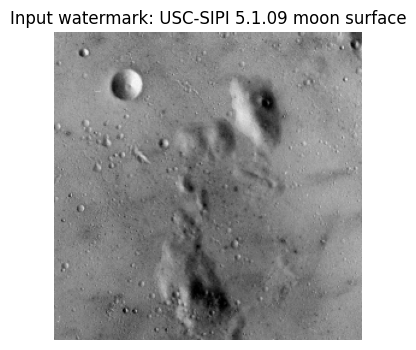

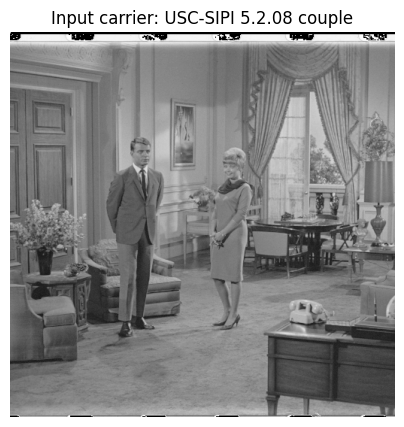

In [5]:
loader = ImageFileLoader()
watermark_image = loader.load_grayscale(sample_paths["watermark_moon_256"])
carrier_image = loader.load_grayscale(sample_paths["carrier_couple_512"])

print(f"Watermark size: {len(watermark_image)}x{len(watermark_image[0])}")
print(f"Carrier size:   {len(carrier_image)}x{len(carrier_image[0])}")
show_image(watermark_image, "Input watermark: USC-SIPI 5.1.09 moon surface", size=4)
show_image(carrier_image, "Input carrier: USC-SIPI 5.2.08 couple", size=5)


## 2. NEQR Encoding Summary

The implementation creates an inspectable NEQR-like description, not a full quantum statevector.

Important implementation note: the rest of the embedding pipeline does **not** consume the `NEQREncodedImage` object as its working data structure. The NEQR object is kept in the pipeline context for explanation/debugging, while the actual AQSM/HDWM operations consume ordinary Python grayscale image matrices: nested `list[list[int]]` values with pixels in `[0, 255]`.

So in this notebook:

- `watermark_neqr` and `carrier_neqr` show what the NEQR basis-state description looks like.
- `watermark_image` and `carrier_image` are the actual data passed into scale calculation, histogram analysis, bit-plane decomposition, AQSM construction, and HDWM embedding.

For real `512x512` images, printing every NEQR basis term would be too noisy, so we inspect counts and a few terms, then show a small crop of the matrix data that the pipeline actually ingests.


In [6]:
neqr_encoder = NEQREncoder()
watermark_neqr = neqr_encoder.encode(watermark_image)
carrier_neqr = neqr_encoder.encode(carrier_image)

parameter_table("NEQR summary", {
    "watermark side exponent": watermark_neqr.side_exponent,
    "watermark amplitude": watermark_neqr.amplitude,
    "watermark term count": len(watermark_neqr.terms),
    "carrier side exponent": carrier_neqr.side_exponent,
    "carrier amplitude": carrier_neqr.amplitude,
    "carrier term count": len(carrier_neqr.terms),
})

print("First three watermark NEQR-like terms:")
for term in watermark_neqr.terms[:3]:
    print(" ", term)

print("\nActual data consumed by the embedding pipeline:")
print(f"watermark_image type: {type(watermark_image).__name__}")
print(f"watermark_image[0] type: {type(watermark_image[0]).__name__}")
print(f"watermark_image shape: {len(watermark_image)} x {len(watermark_image[0])}")
print("Top-left 8x8 watermark grayscale matrix crop:")
for row in watermark_image[:8]:
    print(row[:8])

print(f"\ncarrier_image shape: {len(carrier_image)} x {len(carrier_image[0])}")
print("Top-left 8x8 carrier grayscale matrix crop:")
for row in carrier_image[:8]:
    print(row[:8])


NEQR summary
  watermark side exponent: 8
  watermark amplitude: 0.00390625
  watermark term count: 65536
  carrier side exponent: 9
  carrier amplitude: 0.001953125
  carrier term count: 262144
First three watermark NEQR-like terms:
  NEQRPixelTerm(grayscale_bits='10010000', y_bits='00000000', x_bits='00000000')
  NEQRPixelTerm(grayscale_bits='10100000', y_bits='00000000', x_bits='00000001')
  NEQRPixelTerm(grayscale_bits='10010000', y_bits='00000000', x_bits='00000010')

Actual data consumed by the embedding pipeline:
watermark_image type: list
watermark_image[0] type: list
watermark_image shape: 256 x 256
Top-left 8x8 watermark grayscale matrix crop:
[144, 160, 144, 146, 153, 155, 149, 151]
[144, 160, 144, 146, 153, 155, 149, 151]
[142, 151, 144, 146, 153, 151, 148, 148]
[160, 158, 148, 144, 140, 129, 140, 153]
[162, 148, 140, 155, 138, 144, 132, 155]
[164, 168, 155, 148, 148, 155, 155, 158]
[164, 162, 157, 158, 148, 155, 149, 146]
[162, 149, 160, 158, 149, 144, 142, 144]

carrier_i

## 3. Scale And Histogram Parameters

This step computes the scale parameters used by AQSM and the histogram parameters used by HDWM.

### Scale Parameters

Let the watermark image size be:

$$
2^m \times 2^m
$$

and the carrier image size be:

$$
2^n \times 2^n
$$

The parameters are:

| Parameter | Formula | Meaning |
|---|---:|---|
| `m` | `log2(watermark_side)` | Watermark side-length exponent. A `256x256` watermark has `m = 8`. |
| `n` | `log2(carrier_side)` | Carrier side-length exponent. A `512x512` carrier has `n = 9`. |
| `r` | `n - m` | Scale factor. For `r = 1`, the carrier is twice as wide and twice as tall as the watermark. |
| `beta` | `2` if `r = 1`; otherwise `r` | Helper parameter from the paper used to compute `alpha`. |
| `alpha` | `2^(2*beta - 3) - 1` | Controls how many low/high bit-plane block sets AQSM prepares. |
| `d` | `1` if `r = 1`; otherwise `r` | QBA aggregation level. For `r = 1`, four watermark-sized blocks become one carrier-sized block. |
| `q` | `4` if `r = 1`; otherwise `4^(r-d)` | Number of AQSM binary outputs declared by the paper after QBA level `d`. |

For the current implementation, `r = 1` is the supported path because the paper explicitly states the three AQSM watermarks that are actually embedded for this case.

### Histogram Parameters

The watermark histogram counts how many pixels have each grayscale value:

$$
h(g) = \text{number of watermark pixels with value } g
$$

The cumulative histogram is:

$$
H(g) = \sum_{x=0}^{g} h(x)
$$

The paper divides grayscale values into:

- dark interval: `0..127`
- bright interval: `128..255`

The dark and bright probabilities are:

$$
T_{dark} = \frac{H(127)}{N}
$$

$$
T_{bright} = 1 - T_{dark}
$$

In this notebook, `N` uses the natural denominator, the number of watermark pixels:

$$
N = 2^m \times 2^m
$$

The paper prints `2^m * 2^n` as the denominator, so the implementation also supports `denominator_mode="paper"` for comparison. The default here is `"natural"`.

HDWM uses threshold:

$$
\lambda = 0.5
$$

The first branch parameter is:

$$
\tau_1 =
\begin{cases}
0, & |T_{bright} - T_{dark}| < \lambda \\
1, & |T_{bright} - T_{dark}| \ge \lambda
\end{cases}
$$

Interpretation:

- `tau1 = 0`: watermark histogram is not strongly biased toward dark or bright values.
- `tau1 = 1`: watermark histogram is strongly biased.

If `tau1 = 1`, the second branch parameter is:

$$
\tau_2 =
\begin{cases}
0, & T_{dark} \ge \frac{1 + \lambda}{2} \\
1, & T_{bright} \ge \frac{1 + \lambda}{2}
\end{cases}
$$

Interpretation:

- `tau2 = 0`: strongly dark watermark.
- `tau2 = 1`: strongly bright watermark.
- `tau2 = None`: unused because `tau1 = 0`.

These two parameters choose the HDWM embedding rule for each AQSM bit `w`, carrier LSB target `b'`, and carrier MSB-xor bit `V`:

$$
\tau_1 = 0: \quad b' = w
$$

$$
\tau_1 = 1, \tau_2 = 0: \quad b' = w \oplus V
$$

$$
\tau_1 = 1, \tau_2 = 1: \quad b' = w \oplus (1 - V)
$$


In [7]:
scale_calculator = ScaleParameterCalculator()
scale_parameters = scale_calculator.compute(watermark_image, carrier_image)
parameter_table("Scale parameters", scale_parameters.__dict__)

histogram_analyzer = HistogramAnalyzer()
histogram_parameters = histogram_analyzer.analyze(
    watermark_image=watermark_image,
    scale_parameters=scale_parameters,
    denominator_mode="natural",
)
parameter_table("Histogram / HDWM parameters", {
    "dark_count": histogram_parameters.dark_count,
    "bright_count": histogram_parameters.bright_count,
    "denominator": histogram_parameters.denominator,
    "T_dark": histogram_parameters.t_dark,
    "T_bright": histogram_parameters.t_bright,
    "tau1": histogram_parameters.tau1,
    "tau2": histogram_parameters.tau2,
})


Scale parameters
  watermark_side_exponent: 8
  carrier_side_exponent: 9
  scale_factor: 1
  beta: 2
  alpha: 1
  aggregation_level: 1
  q_outputs: 4
Histogram / HDWM parameters
  dark_count: 29148
  bright_count: 36388
  denominator: 65536
  T_dark: 0.44476318359375
  T_bright: 0.55523681640625
  tau1: 0
  tau2: None


## 4. Bit-Plane Decomposition

`w1` is the least significant bit plane and `w8` is the most significant bit plane.


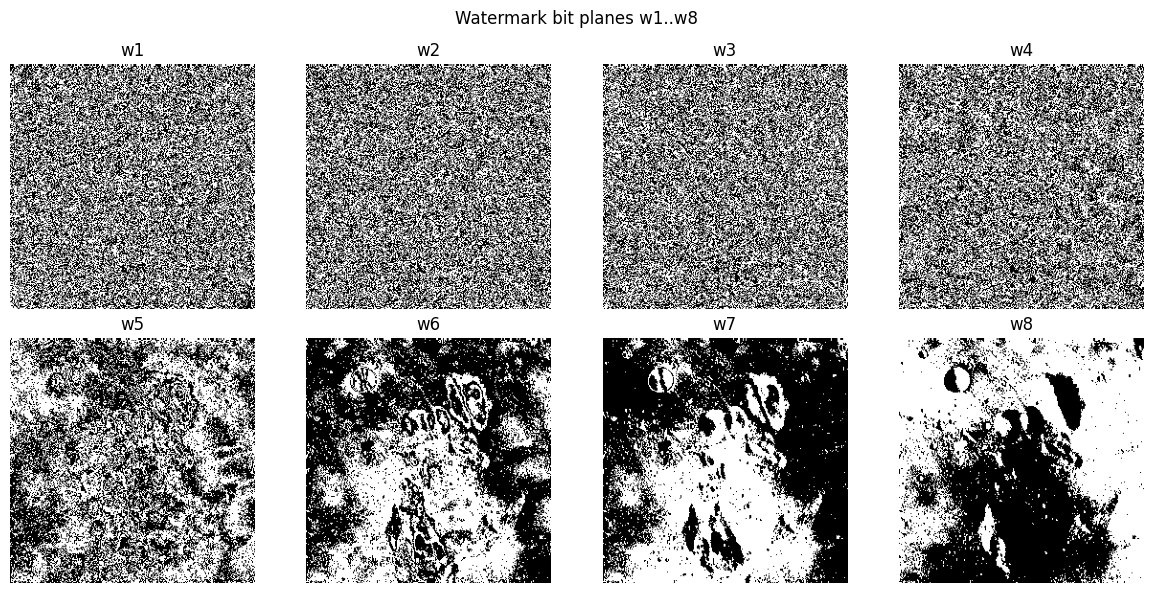

In [8]:
bit_plane_decomposer = BitPlaneDecomposer()
bit_planes = bit_plane_decomposer.decompose(watermark_image)
show_grid(
    [(name, bit_planes[name]) for name in sorted(bit_planes, key=lambda item: int(item[1:]))],
    "Watermark bit planes w1..w8",
    binary=True,
    columns=4,
    size=3,
)


## 5. AQSM Watermark Construction

For `r = 1`, the implemented builder uses the three AQSM block sets explicitly stated in the paper.


Paper-declared AQSM output count q: 4
Actually embedded AQSM images: 3


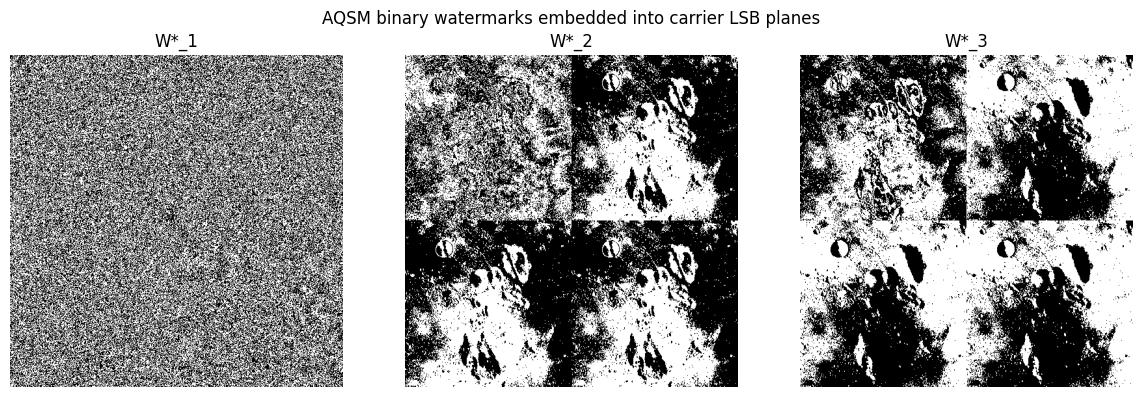

In [9]:
aqsm_builder = AQSMWatermarkBuilder()
aqsm_result = aqsm_builder.build(bit_planes, scale_parameters)

print(f"Paper-declared AQSM output count q: {aqsm_result.declared_output_count}")
print(f"Actually embedded AQSM images: {len(aqsm_result.embedded_watermarks)}")
show_grid(
    [(f"W*_{index}", image) for index, image in enumerate(aqsm_result.embedded_watermarks, start=1)],
    "AQSM binary watermarks embedded into carrier LSB planes",
    binary=True,
    columns=3,
    size=4,
)


## 6. Carrier MSB XOR Matrix

For `r = 1`, `eta = 0`, so `V_eta` is computed from the XOR of the three carrier MSBs.


eta = 0


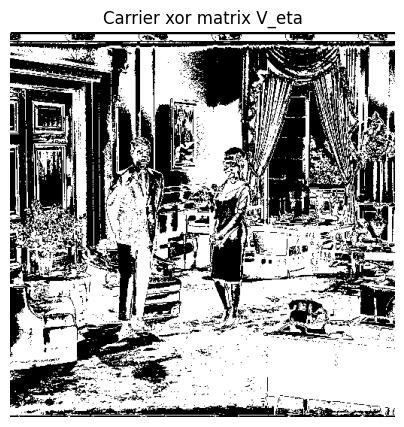

In [10]:
eta = HDWMEmbedder.compute_eta(scale_parameters)
xor_matrix = CarrierXorCalculator().compute(carrier_image, eta=eta)
print(f"eta = {eta}")
show_image(xor_matrix, "Carrier xor matrix V_eta", binary=True, size=5)


## 7. HDWM Embedding

The embedder writes the three AQSM images into carrier bit planes 0, 1, and 2.


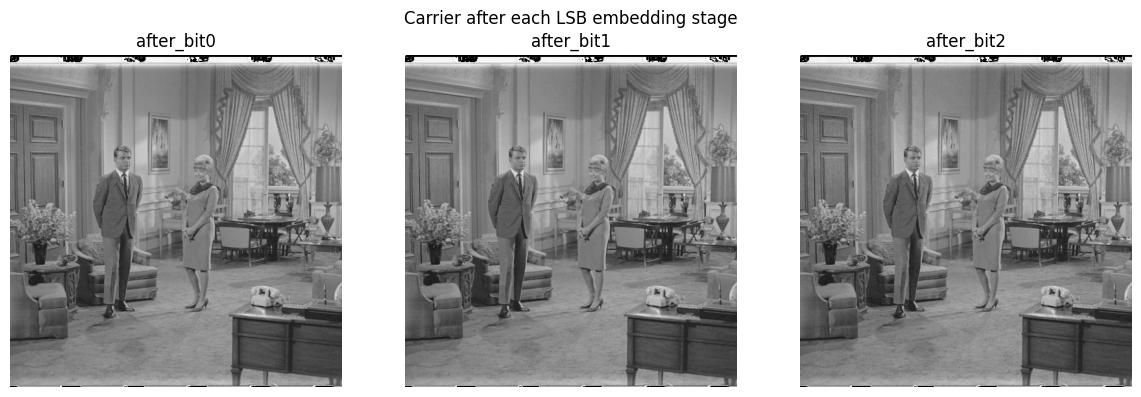

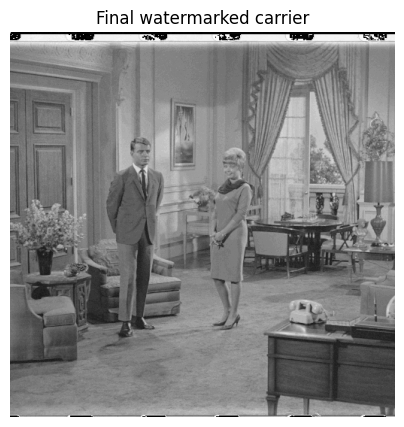

In [11]:
embedder = HDWMEmbedder()
embedding_result = embedder.embed(
    carrier_image=carrier_image,
    aqsm_result=aqsm_result,
    histogram_parameters=histogram_parameters,
    scale_parameters=scale_parameters,
)

stage_images = [(name, image) for name, image in embedding_result.intermediate_images.items()]
show_grid(stage_images, "Carrier after each LSB embedding stage", columns=3, size=4)
show_image(embedding_result.final_image, "Final watermarked carrier", size=5)


## 8. Final Watermarked Output

This section shows the final watermarked carrier image by itself and saves it as a PNG preview under `example_outputs/`.


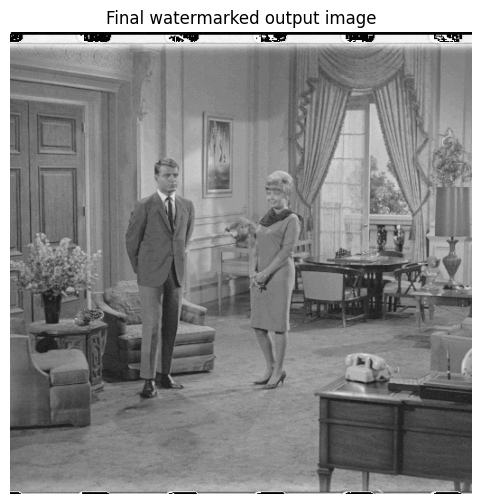

Saved final watermarked output to: example_outputs\final_watermarked_output.png


In [12]:
final_output_path = loader.save_png(
    embedding_result.final_image,
    Path("example_outputs") / "final_watermarked_output.png",
)

show_image(embedding_result.final_image, "Final watermarked output image", size=6)
print(f"Saved final watermarked output to: {final_output_path}")


## 9. Difference Image And Report

The difference image is scaled for visibility. The actual carrier modifications are LSB-plane changes.


Maximum absolute pixel change: 7


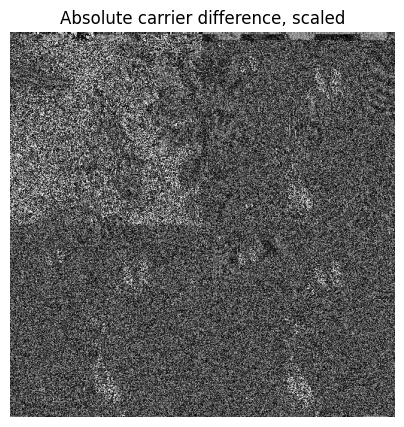

In [13]:
diff = [
    [abs(original - watermarked) for original, watermarked in zip(original_row, watermarked_row)]
    for original_row, watermarked_row in zip(carrier_image, embedding_result.final_image)
]
max_diff = max(max(row) for row in diff)
visible_diff = [[round((value / max_diff) * 255) if max_diff else 0 for value in row] for row in diff]

print(f"Maximum absolute pixel change: {max_diff}")
show_image(visible_diff, "Absolute carrier difference, scaled", size=5)


In [14]:
from aqsm_embedding import EmbeddingContext

context = EmbeddingContext(
    watermark_neqr=watermark_neqr,
    carrier_neqr=carrier_neqr,
    scale_parameters=scale_parameters,
    histogram_parameters=histogram_parameters,
    bit_planes=bit_planes,
    aqsm_result=aqsm_result,
    embedding_result=embedding_result,
)

report_path = EmbeddingReportWriter().write(
    output_directory="example_outputs",
    watermark_image=watermark_image,
    carrier_image=carrier_image,
    context=context,
    metadata={
        "notebook": "aqsm_watermark_embedding_walkthrough.ipynb",
        "dataset": USCSIPISampleDataset.DATASET_PAGE_URL,
        "watermark": str(sample_paths["watermark_moon_256"]),
        "carrier": str(sample_paths["carrier_couple_512"]),
    },
)
report_path


'example_outputs\\aqsm_report.html'